PyTorch project to predict blood pressure reduction from drug dosage.
This helps doctors find safe amounts.
useing nn.Module for a clean model.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
dosage = torch.tensor([[10.0], [20.0], [30.0], [40.0], [50.0],
                       [60.0], [70.0], [80.0], [90.0], [100.0]])

# True rule: BP reduction = 5 - 0.5 * dosage + noise (mmHg)
true_w = torch.tensor([[-0.5]])  # Slope: change per mg
true_b = torch.tensor([5.0])      # Base reduction without dose
noise = torch.randn(10, 1) * 2    # Random variation like patient differences
bp_reduction = dosage @ true_w + true_b + noise

print("Dosage:", dosage[:3])
print("True reductions:", bp_reduction[:3])

Dosage: tensor([[10.],
        [20.],
        [30.]])
True reductions: tensor([[ 1.7618],
        [-6.0352],
        [-6.6029]])


In [17]:

class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.w = nn.Parameter(torch.randn(1,1))
        self.b = nn.Parameter(torch.randn(1))

    def forward(self,x):
        return x @ self.w + self.b
model = LinearModel()

print("Starting w:", model.w.item())
print("Starting b:", model.b.item())   

Starting w: -0.3614017963409424
Starting b: -0.8246790766716003


In [18]:
pred = model(dosage)  # Forward: the guess
loss = ((pred - bp_reduction) ** 2).mean()

print("First predictions:", pred[:3])
print("Loss:", loss.item())

First predictions: tensor([[ -4.4387],
        [ -8.0527],
        [-11.6667]], grad_fn=<SliceBackward0>)
Loss: 24.922260284423828


In [19]:
loss.backward()  
print("Gradient for w:", model.w.grad.item())
print("Gradient for b:", model.b.grad.item())

Gradient for w: 453.6057434082031
Gradient for b: 3.664804458618164


In [20]:
optimizer = optim.SGD(model.parameters(), lr=0.0001)
optimizer.step()  # Apply update
optimizer.zero_grad()  # Clear gradients

print("Updated w:", model.w.item())
print("Updated b:", model.b.item())

Updated w: -0.40676236152648926
Updated b: -0.8250455856323242


In [21]:
epochs = 500

for epoch in range(epochs):
    pred = model(dosage)
    loss = ((pred - bp_reduction) ** 2).mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: w={model.w.item():.2f}, b={model.b.item():.2f}, loss={loss.item():.2f}")

Epoch 50: w=-0.42, b=-0.81, loss=11.52
Epoch 100: w=-0.42, b=-0.80, loss=11.48


Epoch 150: w=-0.42, b=-0.78, loss=11.45
Epoch 200: w=-0.42, b=-0.77, loss=11.41
Epoch 250: w=-0.42, b=-0.76, loss=11.37
Epoch 300: w=-0.42, b=-0.74, loss=11.33
Epoch 350: w=-0.42, b=-0.73, loss=11.29
Epoch 400: w=-0.42, b=-0.71, loss=11.25
Epoch 450: w=-0.42, b=-0.70, loss=11.21
Epoch 500: w=-0.42, b=-0.69, loss=11.18


In [22]:
# Predict for 55 mg
new_dose = torch.tensor([[55.0]])
pred_reduction = model(new_dose)
print("Predicted BP reduction for 55 mg:", pred_reduction.item())

# Safe dosage for 20 mmHg reduction
target_reduction = 20.0
optimal_dose = (target_reduction - model.b.item()) / model.w.item()
print("Dosage for 20 mmHg reduction:", optimal_dose)

Predicted BP reduction for 55 mg: -23.91181755065918
Dosage for 20 mmHg reduction: -48.98551020637167


NameError: name 'np' is not defined

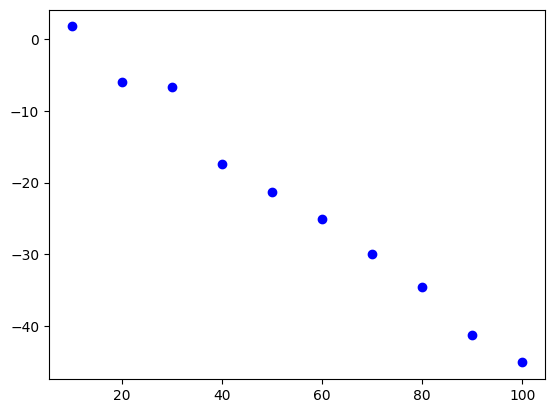

In [23]:
plt.scatter(dosage.numpy(), bp_reduction.numpy(), color='blue', label='Data')
x_line = np.linspace(0, 110, 100)
plt.plot(x_line, model.w.item() * x_line + model.b.item(), color='orange', label='Learned model')
plt.xlabel('Dosage (mg)')
plt.ylabel('BP Reduction (mmHg)')
plt.legend()
plt.show()